# Note to Professor

For your convenience, the complete report is presented at the end of this notebook after the coding and analysis sections. The report includes the research question, group definition, statistical methods, figures, logistic regression results, and the final interpretation and conclusion.


In [1]:
import pandas as pd

# 讀取資料
df = pd.read_csv("YRBS_2007.csv")

# 保留要分析的變數
data = df[['CurrentAlcoholUse', 'ConsideredSuicide']]

# 移除缺失值
data = data.dropna()

# 看前幾筆資料確認有沒有成功
data.head()

,CurrentAlcoholUse,ConsideredSuicide
3,1.0,1.0
5,1.0,2.0
6,1.0,2.0
7,1.0,2.0
8,1.0,2.0


In [2]:
print(data['CurrentAlcoholUse'].value_counts())
print()
print(data['ConsideredSuicide'].value_counts())

CurrentAlcoholUse
1.0    6926
2.0    2726
3.0    1367
4.0     836
5.0     551
7.0     120
6.0     104
Name: count, dtype: int64

ConsideredSuicide
2.0    10767
1.0     1863
Name: count, dtype: int64


In [3]:
# 1 = Yes, 2 = No
data['Suicide'] = data['ConsideredSuicide'].replace({1:1, 2:0})

data[['CurrentAlcoholUse','Suicide']].head()

,CurrentAlcoholUse,Suicide
3,1.0,1.0
5,1.0,0.0
6,1.0,0.0
7,1.0,0.0
8,1.0,0.0


In [4]:
!pip install statsmodels
import statsmodels.api as sm

X = sm.add_constant(data['CurrentAlcoholUse'])
y = data['Suicide']

model = sm.Logit(y, X).fit()

print(model.summary())

##coef>0=喝酒越頻繁，自殺意念越高。


Optimization terminated successfully.
         Current function value: 0.408129
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Suicide   No. Observations:                12630
Model:                          Logit   Df Residuals:                    12628
Method:                           MLE   Df Model:                            1
Date:                Mon, 15 Jun 2026   Pseudo R-squ.:                 0.02445
Time:                        13:48:36   Log-Likelihood:                -5154.7
converged:                       True   LL-Null:                       -5283.9
Covariance Type:            nonrobust   LLR p-value:                 3.827e-58
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.3361      0.046    -51.221      0.000      -2.426      -2.247
CurrentA

In [5]:
import numpy as np

np.exp(0.2805)
##喝酒頻率每增加一個等級，出現自殺意念的機率增加 32%

np.float64(1.323791542662401)

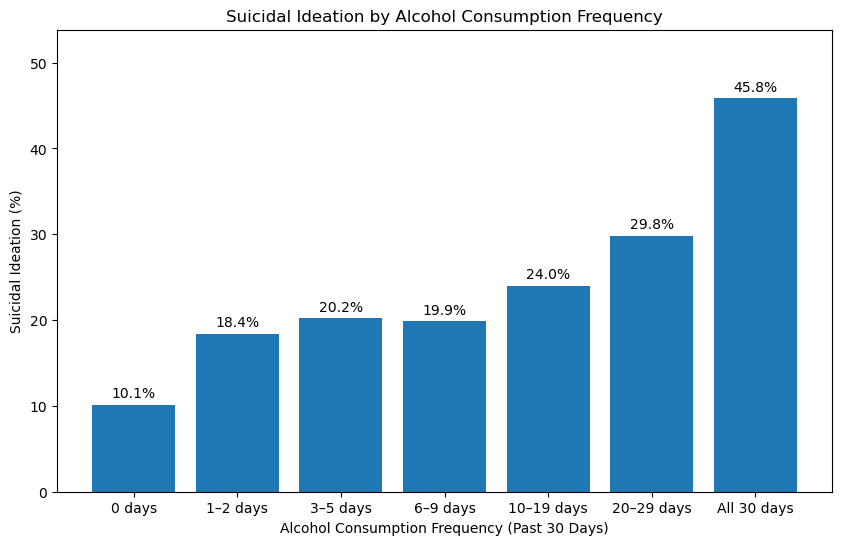

In [9]:
import matplotlib.pyplot as plt

# 計算各飲酒頻率的自殺意念比例 (%)
suicide_rate = data.groupby('CurrentAlcoholUse')['Suicide'].mean() * 100

# YRBS 飲酒頻率標籤
labels = [
    "0 days",
    "1–2 days",
    "3–5 days",
    "6–9 days",
    "10–19 days",
    "20–29 days",
    "All 30 days"
]

# 建立圖表
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, suicide_rate.values)

# 在長條上標示百分比
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        va='bottom'
    )

# 圖表標題與座標軸
plt.title("Suicidal Ideation by Alcohol Consumption Frequency")
plt.xlabel("Alcohol Consumption Frequency (Past 30 Days)")
plt.ylabel("Suicidal Ideation (%)")

# Y 軸範圍
plt.ylim(0, suicide_rate.max() + 8)

plt.show()

In [ ]:
##Figure 1 shows that the prevalence of suicidal ideation increased as alcohol consumption frequency increased. Adolescents who did not drink reported a suicidal ideation rate of 10.1%, whereas those who drank on all 30 days had a rate of 45.8%. This suggests a positive association between alcohol use frequency and suicidal ideation.

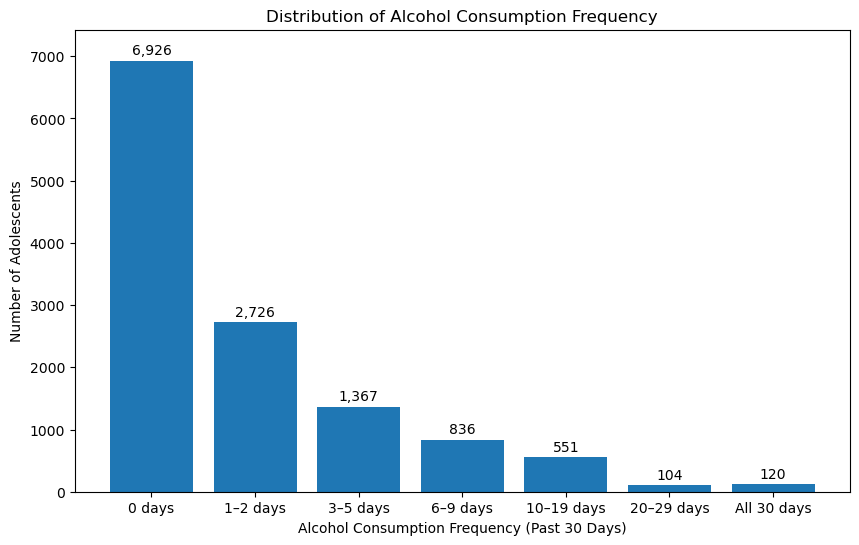

In [12]:
drink_count = data['CurrentAlcoholUse'].value_counts().sort_index()

drink_count

import matplotlib.pyplot as plt

# X軸標籤
labels = [
    "0 days",
    "1–2 days",
    "3–5 days",
    "6–9 days",
    "10–19 days",
    "20–29 days",
    "All 30 days"
]

plt.figure(figsize=(10, 6))

bars = plt.bar(labels, drink_count.values)

# 在長條上標示人數
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f"{int(height):,}",
        ha='center',
        va='bottom'
    )

plt.title("Distribution of Alcohol Consumption Frequency")
plt.xlabel("Alcohol Consumption Frequency (Past 30 Days)")
plt.ylabel("Number of Adolescents")

plt.ylim(0, max(drink_count.values) + 500)

plt.show()

In [13]:
##Figure 2 shows that most adolescents reported no alcohol use in the past 30 days. The number of participants decreased as drinking frequency increased, indicating that heavy drinking was relatively uncommon in this sample.

# Final Project

# Research Question

## Does current alcohol use predict suicidal ideation among adolescents?

This study aims to investigate whether alcohol consumption frequency is associated with suicidal ideation among adolescents using the 2007 Youth Risk Behavior Survey (YRBS) dataset.

**Research Question:**

> Does current alcohol use predict suicidal ideation among adolescents?

中文：

本研究利用 2007 年 YRBS 資料，探討青少年目前的飲酒狀況是否能預測其自殺意念。

---

# Group Definition

## Predictor Variable: Current Alcohol Use

Participants were asked:

> During the past 30 days, on how many days did you have at least one drink of alcohol?

The variable was coded as follows:

| Code | Alcohol Consumption Frequency |
|---|---|
| 1 | 0 days |
| 2 | 1–2 days |
| 3 | 3–5 days |
| 4 | 6–9 days |
| 5 | 10–19 days |
| 6 | 20–29 days |
| 7 | All 30 days |

---

## Response Variable: Considered Suicide

Participants were asked:

> During the past 12 months, did you ever seriously consider attempting suicide?

The responses were recoded into a binary variable:

| Original Code | Recoded Value |
|---|---|
| 1 = Yes | 1 |
| 2 = No | 0 |

---

# Statistical Method

Because the response variable (suicidal ideation) is binary (Yes/No), logistic regression was used to examine the association between alcohol consumption frequency and suicidal ideation.

The logistic regression model can be expressed as:

log(p / (1 − p)) = β₀ + β₁(CurrentAlcoholUse)

where:

- p = probability of suicidal ideation
- β₀ = intercept
- β₁ = effect of alcohol consumption frequency

中文：

由於反應變數為二元變數（有／無自殺意念），因此本研究採用 Logistic Regression 分析飲酒頻率與自殺意念之間的關係。

---

# Figure 1. Suicidal Ideation by Alcohol Consumption Frequency

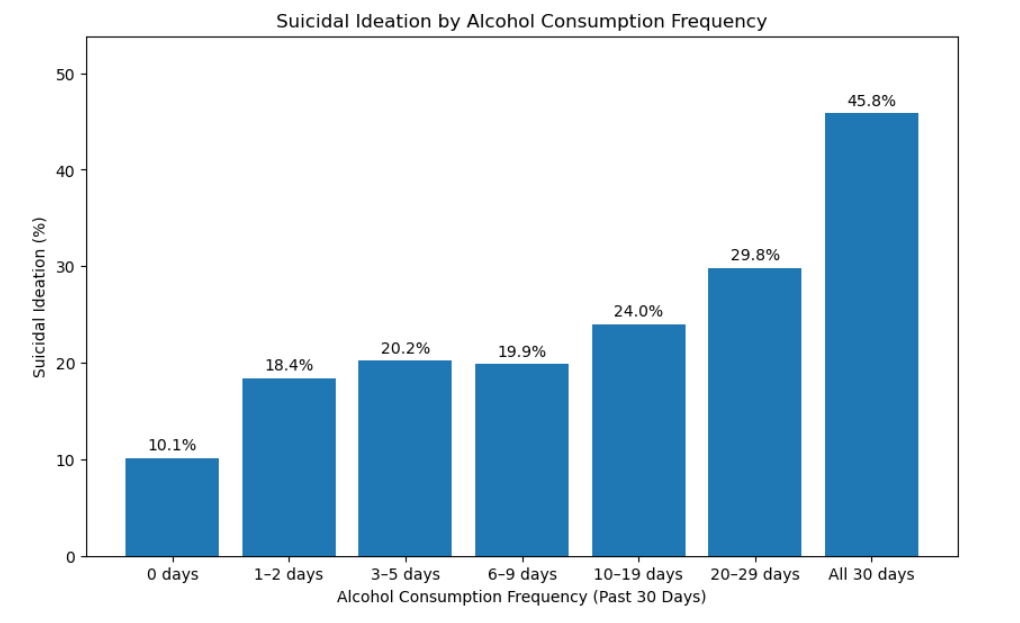

This figure illustrates the prevalence of suicidal ideation across different levels of alcohol consumption frequency.

The prevalence of suicidal ideation increased as alcohol consumption frequency increased.

Suicidal ideation rates by drinking frequency were:

| Alcohol Consumption Frequency | Suicidal Ideation (%) |
|---|---:|
| 0 days | 10.1 |
| 1–2 days | 18.4 |
| 3–5 days | 20.2 |
| 6–9 days | 19.9 |
| 10–19 days | 24.0 |
| 20–29 days | 29.8 |
| All 30 days | 45.8 |

These findings suggest a positive association between alcohol use frequency and suicidal ideation among adolescents.

中文：

圖 1 顯示，隨著飲酒頻率增加，自殺意念比例呈現上升趨勢。未飲酒者的自殺意念比例為 10.1%，而每日飲酒者則高達 45.8%，顯示飲酒頻率與自殺意念可能存在正向關聯。

---

# Figure 2. Distribution of Alcohol Consumption Frequency

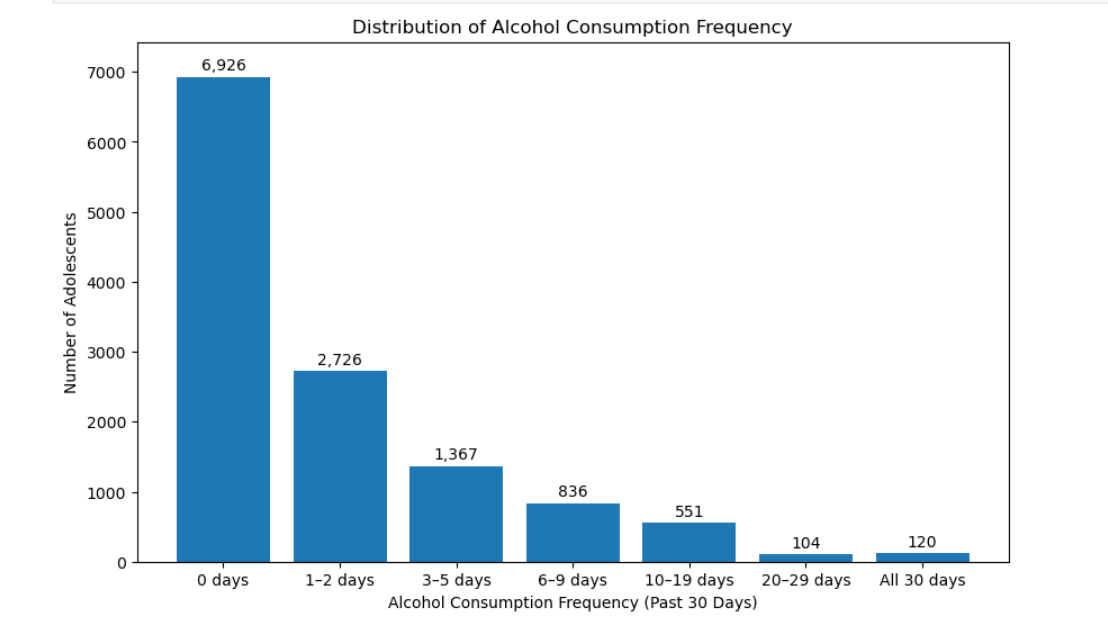

This figure presents the distribution of alcohol consumption frequency among adolescents.

Most participants reported no alcohol use in the past 30 days. The number of participants gradually decreased as drinking frequency increased.

Participant counts were:

| Alcohol Consumption Frequency | Number of Adolescents |
|---|---:|
| 0 days | 6,926 |
| 1–2 days | 2,726 |
| 3–5 days | 1,367 |
| 6–9 days | 836 |
| 10–19 days | 551 |
| 20–29 days | 104 |
| All 30 days | 120 |

These results indicate that heavy drinking was relatively uncommon in this sample.

中文：

圖 2 顯示，大部分青少年在過去 30 天內沒有飲酒，而高頻飲酒者的人數相對較少，代表重度飲酒在本研究樣本中並不常見。

---

# Logistic Regression Results

The logistic regression analysis showed a statistically significant association between alcohol consumption frequency and suicidal ideation.

| Variable | Coefficient (β) | P-value | Odds Ratio |
|---|---:|---:|---:|
| Current Alcohol Use | 0.281 | < 0.001 | 1.324 |

Interpretation:

The odds ratio of 1.324 indicates that each one-category increase in alcohol consumption frequency was associated with a 32.4% increase in the odds of suicidal ideation.

中文：

Odds Ratio 為 1.324，表示飲酒頻率每增加一個等級，青少年出現自殺意念的勝算增加約 32.4%。

---

# Interpretation and Conclusion

This study found that current alcohol use was significantly associated with suicidal ideation among adolescents.

Adolescents who consumed alcohol more frequently were more likely to report suicidal ideation. Although causality cannot be established due to the cross-sectional nature of the survey, the findings suggest that alcohol use may be an important indicator of suicide risk among adolescents.

Future studies should consider additional factors, such as depression, family support, and peer relationships, to better understand the mechanisms underlying this association.

中文：

本研究發現，青少年飲酒頻率與自殺意念之間具有顯著關聯。飲酒頻率越高，其出現自殺意念的可能性也越高。

由於本研究使用橫斷面資料，因此無法推論因果關係，但結果顯示飲酒行為可能是辨識青少年自殺風險的重要指標。未來研究可進一步納入憂鬱程度、家庭支持及同儕關係等因素，以更深入探討其中的機制。